In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
import statsmodels.api as sm
import numpy as np


In [ ]:
file_path = "/content/drive/MyDrive/Analisis matemático/FINALMODELOajustelocal.csv"
df_modelo = pd.read_csv(file_path, encoding='latin1')

In [ ]:
# 1. Crear nuevos dummies

# China moderna (año >= 2000)
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)

# 2. Redefinir X con las nuevas variables
X = df_modelo[[
    "PIB_REAL",
    "POBLACION_TOTAL_CENTRADO",
    "POBLACION_20_24_CENTRADO",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL",
    "VECINO",
    "DUMMY_CHINA_MODERNA",
    "DUMMY_RUSSIA",
    "DUMMY_USA",
    "DUMMY_GERMANY",
    "BOICOT_1980",
    "BOICOT_1984",
    "DUMMY_AUSTRALIA",
    "DUMMY_UK",
    "DUMMY_FRANCE"
]]

# 3. Agregar constante
X = sm.add_constant(X)

# 4. Definir y
y= df_modelo["LOG_PROP_MEDALLAS"]

# 5. Ajustar el modelo
modelo= sm.OLS(y, X).fit()

# 6. Mostrar el resumen del modelo
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:      LOG_PROP_MEDALLAS   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     49.94
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          2.33e-111
Time:                        14:41:08   Log-Likelihood:                -1699.1
No. Observations:                1059   AIC:                             3430.
Df Residuals:                    1043   BIC:                             3510.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [ ]:
import numpy as np

# 1. Predecir log(ŵ_it) con el modelo
log_predicciones = modelo.predict(X)

# 2. Destransformar: volver a escala real (ŵ_it)
predicciones = np.exp(log_predicciones)

# 3. Agregar las predicciones al dataframe de modelado
df_modelo["PROP_MEDALLAS_PREDICHA"] = predicciones

# 4. Opcional: calcular error absoluto entre proporción real y predicha
df_modelo["ERROR_ABSOLUTO"] = np.abs(df_modelo["PROP_MEDALLAS"] - df_modelo["PROP_MEDALLAS_PREDICHA"])

# 5. Mostrar ejemplo de tabla de resultados
resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_TOTALES_POR_PAIS_POR_AÑO",
    "PROP_MEDALLAS",
    "PROP_MEDALLAS_PREDICHA",
    "ERROR_ABSOLUTO"
]].sort_values(by="ERROR_ABSOLUTO", ascending=False)

# Mostrar los 10 países con mayor error
resultados.head(10)


,COUNTRY,YEAR,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,PROP_MEDALLAS,PROP_MEDALLAS_PREDICHA,ERROR_ABSOLUTO
797,Russia,1980,442,0.319134,0.157200,0.161934
188,China,2020,149,0.065236,0.210962,0.145726
189,China,2024,172,0.075938,0.196434,0.120496
1019,United States,1984,352,0.238644,0.126159,0.112485
353,Germany,1972,253,0.208230,0.102079,0.106152
354,Germany,1976,273,0.206818,0.102025,0.104793
796,Russia,1976,286,0.216667,0.124914,0.091753
357,Germany,1988,296,0.187223,0.096312,0.090911
793,Russia,1964,174,0.169096,0.250022,0.080926
1010,United Kingdom,2012,126,0.065150,0.143789,0.078639


In [ ]:
# 1. Primero, recuperar el total de medallas entregadas cada año
total_medallas_por_ano = df_modelo.groupby("YEAR")["MEDALLAS_TOTALES_POR_PAIS_POR_AÑO"].transform("sum")

# 2. Calcular las medallas reales y predichas en números absolutos
df_modelo["MEDALLAS_REALES"] = df_modelo["PROP_MEDALLAS"] * total_medallas_por_ano
df_modelo["MEDALLAS_PREDICHAS"] = df_modelo["PROP_MEDALLAS_PREDICHA"] * total_medallas_por_ano

# 3. Calcular error absoluto en número de medallas
df_modelo["ERROR_ABSOLUTO_MEDALLAS"] = np.abs(df_modelo["MEDALLAS_REALES"] - df_modelo["MEDALLAS_PREDICHAS"])

# 4. Armar la tabla ordenada
tabla_resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_REALES",
    "MEDALLAS_PREDICHAS",
    "ERROR_ABSOLUTO_MEDALLAS"
]].sort_values(by="ERROR_ABSOLUTO_MEDALLAS", ascending=False)

# 5. Mostrar los 10 países con mayor error absoluto
tabla_resultados.head(15)


,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
188,China,2020,148.999999,481.838071,332.838072
189,China,2024,172.000000,444.923219,272.923219
797,Russia,1980,442.000000,217.721628,224.278372
1019,United States,1984,352.000000,186.085197,165.914803
43,Australia,2000,183.000000,337.973111,154.973111
1010,United Kingdom,2012,125.999999,278.087209,152.087210
357,Germany,1988,295.999999,152.269102,143.730898
366,Germany,2024,108.000000,247.150036,139.150036
354,Germany,1976,273.000000,134.673305,138.326695
353,Germany,1972,253.000000,124.025852,128.974149


In [ ]:
tabla_resultados.to_excel('RESULTADOS5.xlsx', index=False)

In [ ]:
df=tabla_resultados

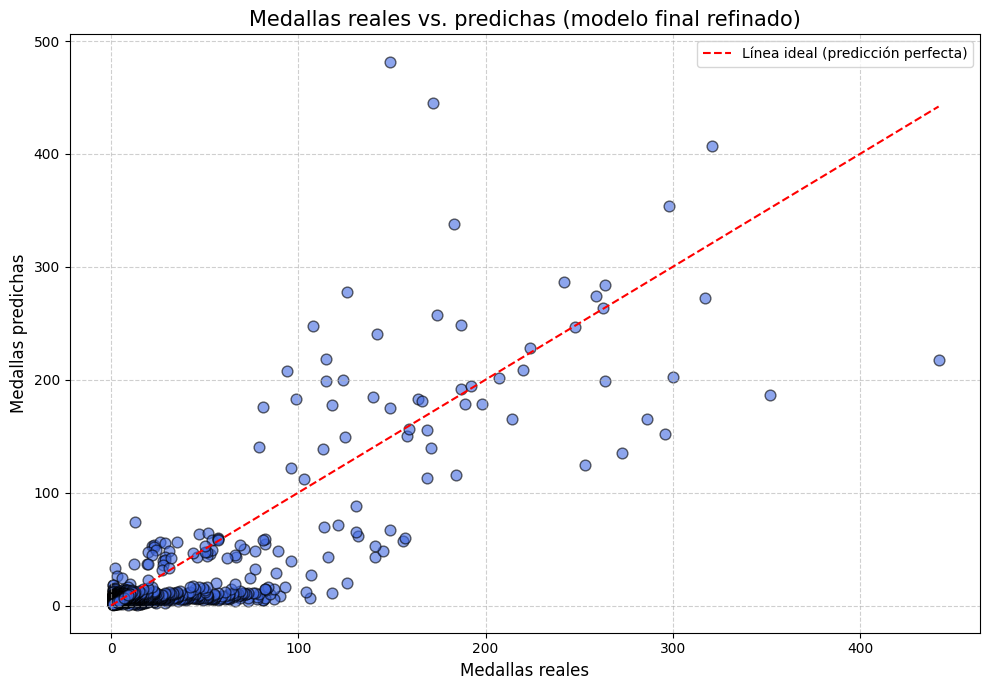

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar archivo de resultados
#df = pd.read_excel("RESULTADOS5.xlsx")  # Asegúrate de tener este archivo en tu carpeta de trabajo

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# 3. Seleccionar las columnas necesarias y eliminar valores nulos
df_grafico = df[["COUNTRY", "YEAR", "MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].dropna()

# 4. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_grafico["MEDALLAS_REALES"],
    df_grafico["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='royalblue',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, df_grafico["MEDALLAS_REALES"].max()],
    [0, df_grafico["MEDALLAS_REALES"].max()],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 5. Etiquetas y formato
plt.title("Medallas reales vs. predichas (modelo final refinado)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Mostrar
plt.show()


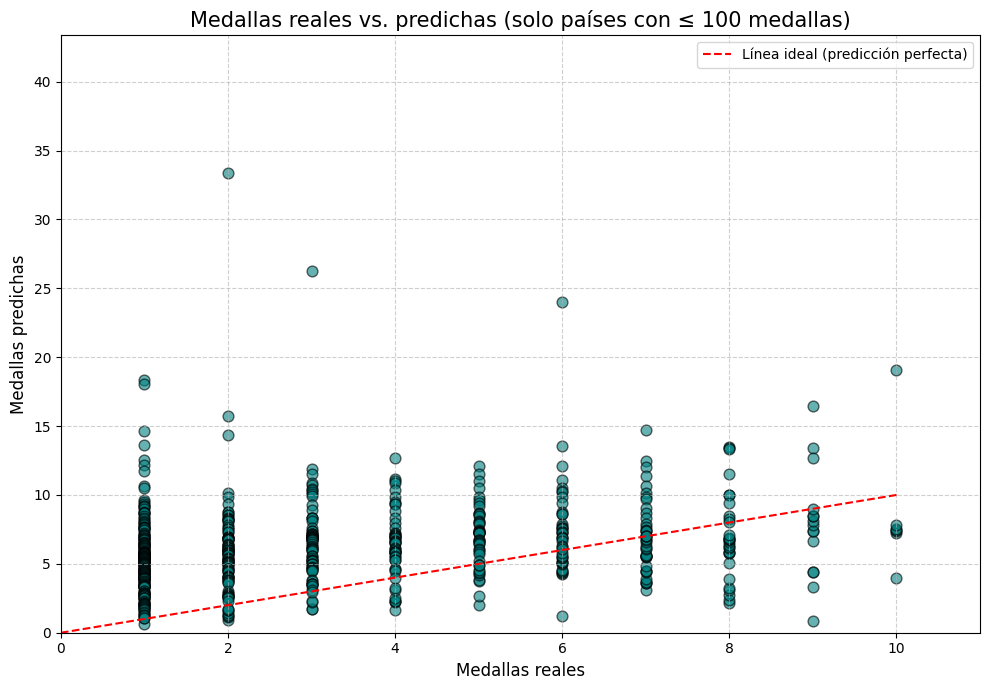

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos
df.columns = df.columns.str.strip()

# 2. Filtrar solo países con hasta 100 medallas reales
df_sub = df[df["MEDALLAS_REALES"] <= 10].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='teal',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, 10],
    [0, 10],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (solo países con ≤ 100 medallas)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.xlim(0, 11)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 5. Mostrar
plt.show()


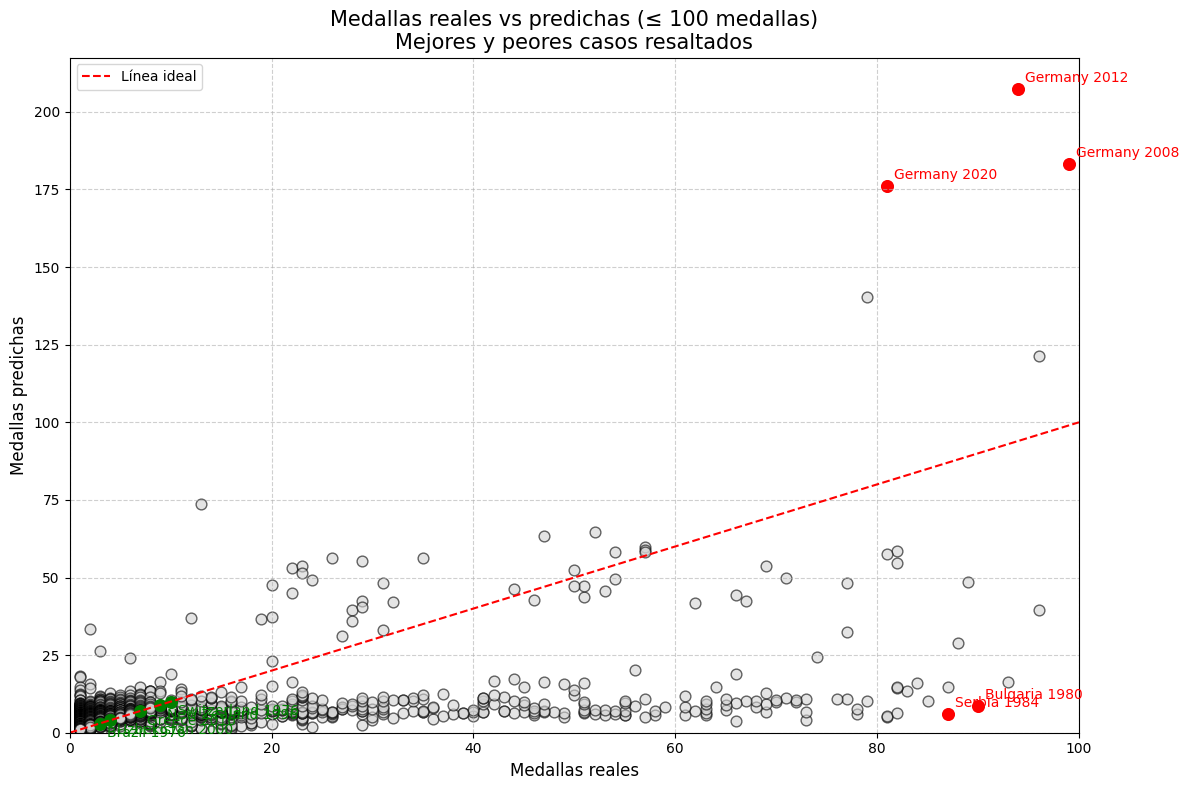

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df.columns = df.columns.str.strip()

# 2. Filtrar países con hasta 100 medallas reales
df_sub = df[df["MEDALLAS_REALES"] <= 100].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Calcular error absoluto
df_sub["ERROR_ABSOLUTO"] = abs(df_sub["MEDALLAS_REALES"] - df_sub["MEDALLAS_PREDICHAS"])

# 4. Seleccionar los 5 peor y 5 mejor predichos
peores = df_sub.sort_values("ERROR_ABSOLUTO", ascending=False).head(5)
mejores = df_sub.sort_values("ERROR_ABSOLUTO", ascending=True).head(5)

# 5. Crear gráfico
plt.figure(figsize=(12, 8))
plt.scatter(df_sub["MEDALLAS_REALES"], df_sub["MEDALLAS_PREDICHAS"],
            alpha=0.6, color='lightgray', edgecolors='black', s=60)

# Dibujar línea de predicción perfecta
plt.plot([0, 100], [0, 100], 'r--', label='Línea ideal')

# Etiquetar los peores
for _, row in peores.iterrows():
    plt.scatter(row["MEDALLAS_REALES"], row["MEDALLAS_PREDICHAS"], color='red', s=70)
    plt.annotate(f"{row['COUNTRY']} {int(row['YEAR'])}",
                 (row["MEDALLAS_REALES"], row["MEDALLAS_PREDICHAS"]),
                 textcoords="offset points", xytext=(5,5), ha='left', color='red')

# Etiquetar los mejores
for _, row in mejores.iterrows():
    plt.scatter(row["MEDALLAS_REALES"], row["MEDALLAS_PREDICHAS"], color='green', s=70)
    plt.annotate(f"{row['COUNTRY']} {int(row['YEAR'])}",
                 (row["MEDALLAS_REALES"], row["MEDALLAS_PREDICHAS"]),
                 textcoords="offset points", xytext=(5,-10), ha='left', color='green')

# Títulos y formato
plt.title("Medallas reales vs predichas (≤ 100 medallas)\nMejores y peores casos resaltados", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
import pandas as pd

# 1. Cargar archivo de resultados
df.columns = df.columns.str.strip()

# 2. Agrupar por país y sumar medallas reales y predichas
tabla_resumen = df.groupby("COUNTRY")[["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].sum().reset_index()

# 3. Calcular el error absoluto total por país
tabla_resumen["ERROR_ABSOLUTO_TOTAL"] = abs(tabla_resumen["MEDALLAS_REALES"] - tabla_resumen["MEDALLAS_PREDICHAS"])

# 4. Renombrar columnas para claridad
tabla_resumen.columns = ["COUNTRY", "MEDALLAS_REALES_TOTALES", "MEDALLAS_PREDICHAS_TOTALES", "ERROR_ABSOLUTO_TOTAL"]

# 5. Ordenar por error total (opcional: puedes cambiar a orden por medallas reales si lo prefieres)
tabla_resumen = tabla_resumen.sort_values("ERROR_ABSOLUTO_TOTAL", ascending=False)

# 6. Mostrar las primeras filas
print(tabla_resumen.head(15))

# (Opcional) Guardar a Excel
tabla_resumen.to_excel("resumen_medallas_totales_con_errores.xlsx", index=False)


         COUNTRY  MEDALLAS_REALES_TOTALES  MEDALLAS_PREDICHAS_TOTALES  \
60         Italy               982.000000                  196.137625   
52       Hungary               780.999999                  134.057810   
63         Japan               960.000003                  330.009911   
82   Netherlands               789.000000                  173.293495   
98       Romania               641.000001                  102.779687   
107  South Korea               641.999999                  110.671712   
16        Brazil               576.000001                  132.717670   
103       Serbia               517.999997                   83.288956   
108        Spain               606.999997                  182.624369   
21        Canada               611.000003                  201.780138   
94        Poland               518.999997                  118.317293   
28          Cuba               424.999997                   93.189743   
24         China              1234.000000          